# Galería de gráficos
## Introducción
Los ejemplos que se muestran provienen de una cohorte sintética, el código puede examinarse al descargar la libreta. Este capítulo está pensado para **ver primero y leer después**. 

Para elegir qué gráfico puede ser el ideal según la estructura de los datos, véase también @holtz_healy_data_to_viz.

| Navegación |  |  |
|---|---|---|
| [Distribuciones](#distribuciones) | [Categorías y composición](#categorias) | [Relaciones](#relaciones) |
| [Comparaciones](#comparaciones) | [Pareados y longitudinales](#longitudinales) | [Estimaciones e incertidumbre](#estimaciones) |
| [Gráficos clínicos](#clinicos) | [Qué conviene evitar](#evitar) |  |

In [1]:
# Imports ---------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.calibration import calibration_curve

# Estilo ----------------------------------------------------------------------
rng = np.random.default_rng(42)
np.random.seed(42)  # jitter reproducible de seaborn
n = 300

PASTEL = {
    "azul": "#A8DADC",
    "coral": "#F4A6A6",
    "salvia": "#BFD8B8",
    "lila": "#C9C2E0",
    "durazno": "#F6D6AD",
    "rosa": "#F2C6DE",
    "gris": "#D9DEE3",
}
DARK = {
    "azul": "#527A86",
    "coral": "#A85F5F",
    "salvia": "#6E826A",
    "lila": "#71688E",
    "gris": "#6B7280",
}
orden = ["Control", "Intervención"]
paleta = {"Control": PASTEL["azul"], "Intervención": PASTEL["coral"]}
hex_cmap = sns.light_palette(DARK["salvia"], as_cmap=True)
corr_cmap = sns.diverging_palette(220, 20, s=45, l=78, center="light", as_cmap=True)

sns.set_theme(style="whitegrid", context="notebook")
sns.set_palette([PASTEL["azul"], PASTEL["coral"], PASTEL["salvia"], PASTEL["lila"], PASTEL["durazno"], PASTEL["rosa"]])
plt.rcParams.update({
    "figure.figsize": (6.4, 4.1),
    "figure.dpi": 120,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": "#C7CDD4",
    "axes.labelcolor": "#374151",
    "xtick.color": "#4B5563",
    "ytick.color": "#4B5563",
    "grid.color": "#E9ECEF",
    "grid.linewidth": 0.8,
    "axes.titleweight": "semibold",
    "legend.frameon": False,
})

# Datos sintéticos ------------------------------------------------------------
def logistic(x):
    return 1 / (1 + np.exp(-x))

edad = np.clip(rng.normal(50, 15, n), 18, 85)
sexo_bin = rng.binomial(1, 0.50, n)
grupo_bin = rng.binomial(1, 0.50, n)

imc = 25 + 0.04 * (edad - 50) + 1.0 * sexo_bin + rng.normal(0, 3, n)
presion_sistolica = 120 + 0.45 * (edad - 50) + 1.2 * (imc - 25) + rng.normal(0, 10, n)

mu_biomarcador = np.exp(1.5 + 0.015 * (edad - 50) + 0.04 * (imc - 25))
shape = 3
biomarcador = rng.gamma(shape, mu_biomarcador / shape)

puntaje_basal = 50 + 0.15 * (edad - 50) + 1.5 * np.log(biomarcador) + rng.normal(0, 8, n)
puntaje_final = puntaje_basal - 6 * grupo_bin + rng.normal(0, 6, n)
cambio_puntaje = puntaje_final - puntaje_basal

p_respuesta = logistic(-0.5 + 1.0 * grupo_bin - 0.03 * (puntaje_basal - 50))
respuesta_bin = rng.binomial(1, p_respuesta)

p_diagnostico = logistic(-1 + 0.04 * (edad - 50) + 0.08 * (imc - 25))
diagnostico = rng.binomial(1, p_diagnostico)
score_prueba = 40 + 15 * diagnostico + 0.10 * (edad - 50) + rng.normal(0, 10, n)
prob_predicha = logistic(-5.2 + 0.09 * score_prueba)

valor_real = 100 + 0.3 * (edad - 50) + rng.normal(0, 12, n)
metodo_a = valor_real + rng.normal(0, 5, n)
metodo_b = valor_real + 2 + rng.normal(0, 6, n)

# Tiempo a evento: menor hazard en intervención
hazard = 0.055 * np.exp(-0.55 * grupo_bin + 0.012 * (edad - 50))
tiempo_evento_real = rng.exponential(1 / hazard)
tiempo_censura = rng.uniform(8, 30, n)
tiempo_evento = np.minimum(tiempo_evento_real, tiempo_censura)
evento = (tiempo_evento_real <= tiempo_censura).astype(int)

# Variable categórica adicional para ejemplos de composición
severidad = pd.cut(
    puntaje_basal,
    bins=[-np.inf, 45, 55, 65, np.inf],
    labels=["Baja", "Moderada", "Alta", "Muy alta"],
    ordered=True,
)

# DataFrame principal ---------------------------------------------------------
df = pd.DataFrame({
    "id": np.arange(1, n + 1),
    "edad": edad,
    "sexo": np.where(sexo_bin == 1, "Hombre", "Mujer"),
    "grupo": np.where(grupo_bin == 1, "Intervención", "Control"),
    "imc": imc,
    "presion_sistolica": presion_sistolica,
    "biomarcador": biomarcador,
    "puntaje_basal": puntaje_basal,
    "puntaje_final": puntaje_final,
    "cambio_puntaje": cambio_puntaje,
    "respuesta": np.where(respuesta_bin == 1, "Sí", "No"),
    "diagnostico": diagnostico,
    "score_prueba": score_prueba,
    "prob_predicha": prob_predicha,
    "metodo_a": metodo_a,
    "metodo_b": metodo_b,
    "tiempo_evento": tiempo_evento,
    "evento": evento,
    "severidad": severidad,
})

# Objetos derivados -----------------------------------------------------------
longitudinal = df.melt(
    id_vars=["id", "grupo"],
    value_vars=["puntaje_basal", "puntaje_final"],
    var_name="momento",
    value_name="puntaje",
)
longitudinal["momento"] = longitudinal["momento"].map({"puntaje_basal": "Basal", "puntaje_final": "Final"})

proporciones = (
    pd.crosstab(df["grupo"], df["respuesta"], normalize="index")
    .mul(100)
    .reindex(index=orden, columns=["Sí", "No"])
)

conteo_severidad = df["severidad"].value_counts(sort=False)

corr_cols = ["edad", "imc", "presion_sistolica", "biomarcador", "puntaje_basal"]
matriz_corr = df[corr_cols].corr()

# Escala para las burbujas: área proporcional al biomarcador
q05, q95 = np.quantile(df["biomarcador"], [0.05, 0.95])
bubble_scaled = np.clip((df["biomarcador"] - q05) / (q95 - q05), 0, 1)
bubble_size = 35 + 420 * bubble_scaled

# Q-Q
qq_theoretical, qq_ordered = stats.probplot(df["edad"], dist="norm", fit=False)
qq_fit = stats.probplot(df["edad"], dist="norm", fit=True)[1]
qq_slope, qq_intercept, _ = qq_fit

# ROC y calibración
fpr, tpr, umbrales = roc_curve(df["diagnostico"], df["score_prueba"])
auc = roc_auc_score(df["diagnostico"], df["score_prueba"])
cal_frac_pos, cal_mean_pred = calibration_curve(df["diagnostico"], df["prob_predicha"], n_bins=8, strategy="quantile")

# Bland-Altman
concordancia = pd.DataFrame({
    "media": (df["metodo_a"] + df["metodo_b"]) / 2,
    "diferencia": df["metodo_b"] - df["metodo_a"],
})
sesgo = concordancia["diferencia"].mean()
de_diff = concordancia["diferencia"].std(ddof=1)
loa_inf = sesgo - 1.96 * de_diff
loa_sup = sesgo + 1.96 * de_diff

# Forest plot: diferencia de medias de cambio por subgrupos
def mean_diff_ci(data):
    a = data.loc[data["grupo"] == "Intervención", "cambio_puntaje"].dropna()
    b = data.loc[data["grupo"] == "Control", "cambio_puntaje"].dropna()
    est = a.mean() - b.mean()
    se = np.sqrt(a.var(ddof=1) / len(a) + b.var(ddof=1) / len(b))
    return est, est - 1.96 * se, est + 1.96 * se

mediana_biomarcador = df["biomarcador"].median()
subgrupos = [
    ("Global", df),
    ("Mujer", df[df["sexo"] == "Mujer"]),
    ("Hombre", df[df["sexo"] == "Hombre"]),
    ("Edad < 50", df[df["edad"] < 50]),
    ("Edad ≥ 50", df[df["edad"] >= 50]),
    ("Biomarcador bajo", df[df["biomarcador"] < mediana_biomarcador]),
    ("Biomarcador alto", df[df["biomarcador"] >= mediana_biomarcador]),
]
forest_rows = []
for nombre, data in subgrupos:
    est, low, high = mean_diff_ci(data)
    forest_rows.append((nombre, est, low, high))
forest = pd.DataFrame(forest_rows, columns=["subgrupo", "estimacion", "inferior", "superior"])

# Kaplan-Meier sin dependencia externa
def km_curve(time, event):
    time = np.asarray(time)
    event = np.asarray(event)
    event_times = np.sort(np.unique(time[event == 1]))
    times = [0.0]
    survival = [1.0]
    s = 1.0
    for t in event_times:
        at_risk = np.sum(time >= t)
        d = np.sum((time == t) & (event == 1))
        s *= (1 - d / at_risk)
        times.append(float(t))
        survival.append(float(s))
    return np.asarray(times), np.asarray(survival)

km = {}
for g in orden:
    d = df[df["grupo"] == g]
    km[g] = km_curve(d["tiempo_evento"], d["evento"])

# Objetos para raincloud
raincloud = {}
for g in orden:
    vals = df.loc[df["grupo"] == g, "cambio_puntaje"].to_numpy()
    grid = np.linspace(vals.min() - 1, vals.max() + 1, 240)
    density = stats.gaussian_kde(vals)(grid)
    density = density / density.max() * 0.28
    jitter = rng.normal(0, 0.035, len(vals))
    raincloud[g] = {"values": vals, "grid": grid, "density": density, "jitter": jitter}

# Selección fija para trayectorias individuales
ids_trayectorias = (
    df.groupby("grupo", sort=False, group_keys=False)
    .sample(n=12, random_state=42)["id"]
)
seleccion_trayectorias = longitudinal[longitudinal["id"].isin(ids_trayectorias)]

(distribuciones)=
## Distribuciones

### Histograma

:::{tip} Cuándo usarlo
:class: simple
**Úsalo para:** ver forma, centro, dispersión y asimetría de una variable cuantitativa.  
**Evita:** interpretar demasiado la forma con pocos datos o con una elección arbitraria de bins.
:::

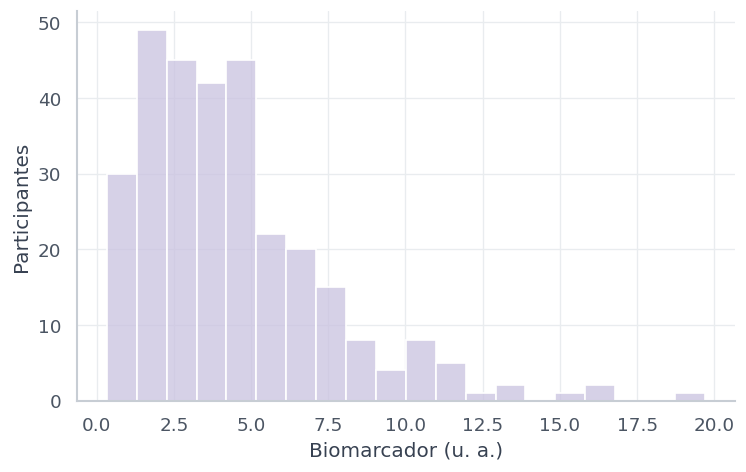

In [2]:
fig, ax = plt.subplots()
sns.histplot(data=df, x="biomarcador", bins=20, color=PASTEL["lila"], edgecolor="white", ax=ax)
ax.set(xlabel="Biomarcador (u. a.)", ylabel="Participantes")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Densidad (KDE)

:::{tip} Cuándo usarlo
:class: simple
**Úsalo para:** comparar suavemente la forma de distribuciones continuas.  
**Evita:** muestras pequeñas, datos discretos o interpretar la curva como si fueran observaciones reales.
:::

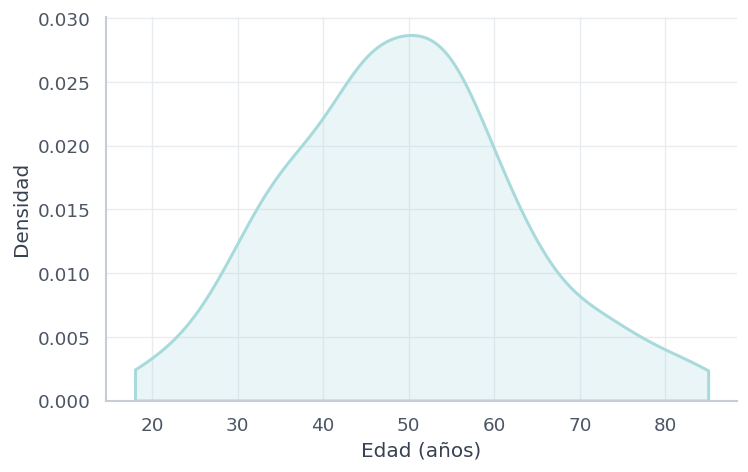

In [3]:
fig, ax = plt.subplots()
sns.kdeplot(data=df, x="edad", fill=True, color=PASTEL["azul"], linewidth=1.8, cut=0, ax=ax)
ax.set(xlabel="Edad (años)", ylabel="Densidad")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### ECDF

:::{tip} Cuándo usarlo
:class: simple
**Úsalo para:** leer percentiles y proporciones acumuladas sin depender de bins ni suavizado.  
**Evita:** usarla si la audiencia necesita reconocer rápidamente la forma de la distribución; el histograma suele ser más intuitivo.
:::

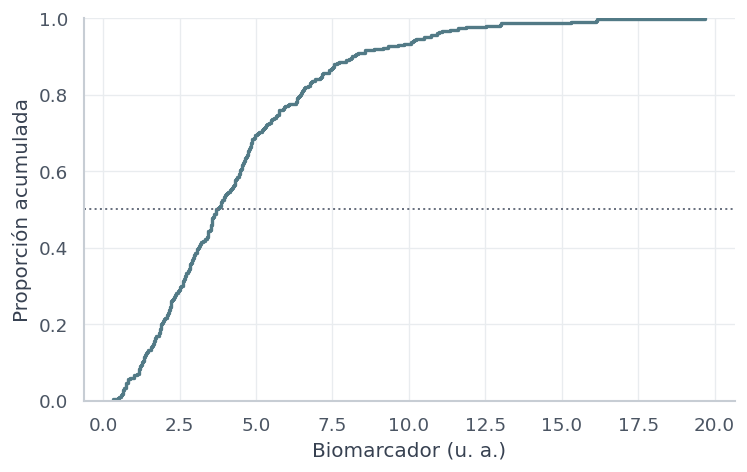

In [4]:
fig, ax = plt.subplots()
sns.ecdfplot(data=df, x="biomarcador", color=DARK["azul"], linewidth=2, ax=ax)
ax.axhline(0.5, color=DARK["gris"], linestyle=":", linewidth=1.2)
ax.set(xlabel="Biomarcador (u. a.)", ylabel="Proporción acumulada", ylim=(0, 1))
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Q–Q plot

:::{tip} Cuándo usarlo
:class: simple
**Úsalo para:** evaluar visualmente si una distribución se aproxima a una distribución teórica, con frecuencia la normal.  
**Evita:** convertirlo en una prueba dicotómica de normalidad; pequeñas desviaciones son esperables.
:::

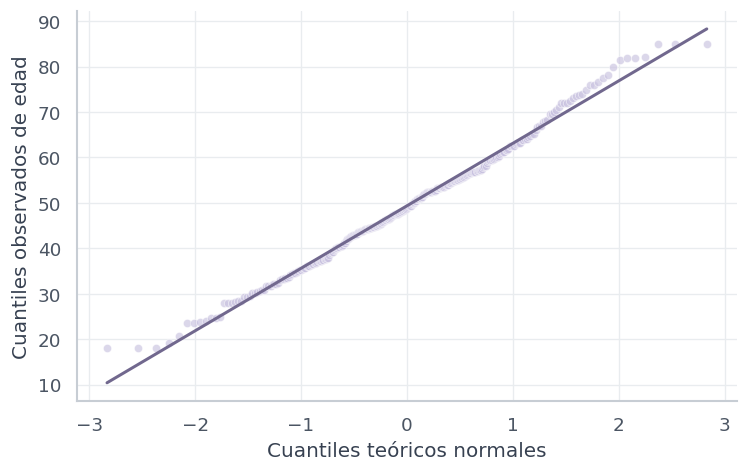

In [5]:
fig, ax = plt.subplots()
ax.scatter(qq_theoretical, qq_ordered, s=24, alpha=0.65, color=PASTEL["lila"], edgecolor="white", linewidth=0.4)
xline = np.array([qq_theoretical.min(), qq_theoretical.max()])
ax.plot(xline, qq_intercept + qq_slope * xline, color=DARK["lila"], linewidth=1.8)
ax.set(xlabel="Cuantiles teóricos normales", ylabel="Cuantiles observados de edad")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Boxplot

:::{tip} Cuándo usarlo
:class: simple
**Úsalo para:** resumir mediana, rango intercuartílico y valores alejados del centro.  
**Evita:** usarlo solo cuando la forma de la distribución importa: la caja puede ocultar multimodalidad y tamaño muestral.
:::

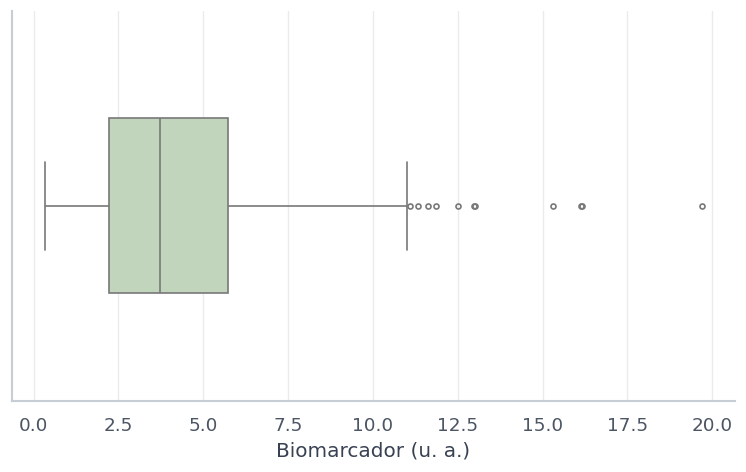

In [6]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x="biomarcador", color=PASTEL["salvia"], width=0.45, fliersize=3, ax=ax)
ax.set(xlabel="Biomarcador (u. a.)", ylabel="")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Violin plot

:::{tip} Cuándo usarlo
:class: simple
**Úsalo para:** mostrar simultáneamente posición y forma de una distribución.  
**Evita:** muestras pequeñas o situaciones donde el suavizado pueda sugerir estructura inexistente.
:::

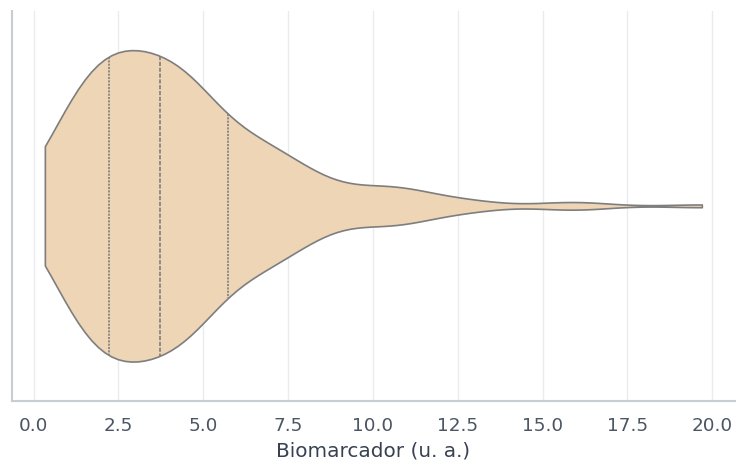

In [7]:
fig, ax = plt.subplots()
sns.violinplot(data=df, x="biomarcador", inner="quart", cut=0, color=PASTEL["durazno"], linewidth=1, ax=ax)
ax.set(xlabel="Biomarcador (u. a.)", ylabel="")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

(categorias)=
## Categorías y composición

### Gráfico de barras

:::{tip} Cuándo usarlo
:class: simple
**Úsalo para:** comparar conteos o valores entre categorías discretas.  
**Evita:** truncar el eje cuando la longitud de la barra codifica magnitud; las barras deben partir de cero.
:::

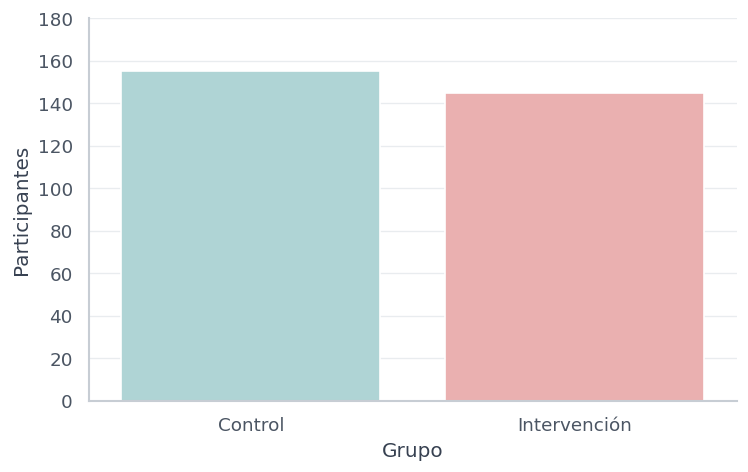

In [8]:
fig, ax = plt.subplots()
sns.countplot(data=df, x="grupo", order=orden, hue="grupo", palette=paleta, legend=False, ax=ax)
ax.set(xlabel="Grupo", ylabel="Participantes", ylim=(0, 180))
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Lollipop plot

:::{tip} Cuándo usarlo
:class: simple
**Úsalo para:** presentar pocas categorías con una apariencia más ligera que las barras.  
**Evita:** muchas categorías o cuando el cero no es un referente interpretable.
:::

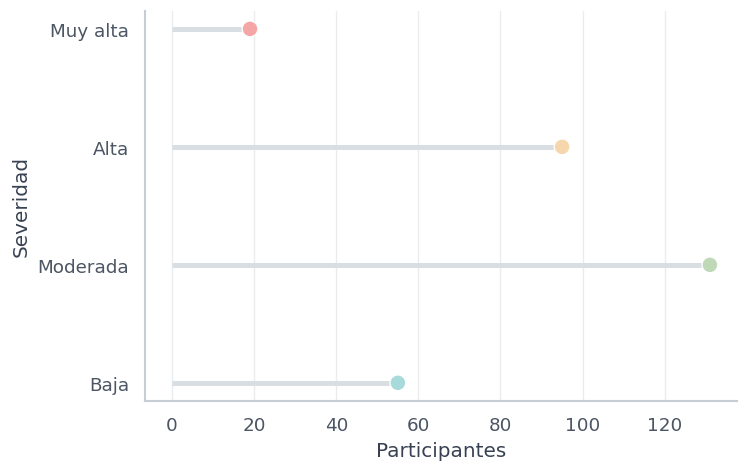

In [9]:
fig, ax = plt.subplots()
y = np.arange(len(conteo_severidad))
ax.hlines(y, 0, conteo_severidad.values, color=PASTEL["gris"], linewidth=3)
ax.scatter(conteo_severidad.values, y, s=90, color=[PASTEL["azul"], PASTEL["salvia"], PASTEL["durazno"], PASTEL["coral"]], edgecolor="white", linewidth=0.8, zorder=3)
ax.set_yticks(y, conteo_severidad.index.astype(str))
ax.set(xlabel="Participantes", ylabel="Severidad")
ax.grid(axis="y", visible=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Gráfico circular (pastel)

:::{warning} Mejor reservarlo para difusión
:class: simple
**Úsalo para:** difusión general cuando hay muy pocas categorías y solo importa una composición aproximada; suele resultar intuitivo para público no técnico.  
**Evita:** comunicación científica y comparaciones precisas: los ángulos y áreas se comparan peor que longitudes; preferir barras.
:::

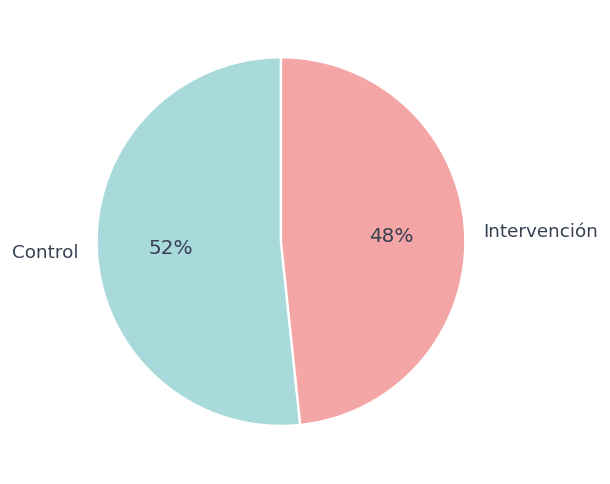

In [10]:
fig, ax = plt.subplots(figsize=(5.4, 4.2))
counts = df["grupo"].value_counts().reindex(orden)
ax.pie(
    counts.values,
    labels=counts.index,
    autopct="%1.0f%%",
    startangle=90,
    colors=[paleta[g] for g in counts.index],
    wedgeprops={"edgecolor": "white", "linewidth": 1.4},
    textprops={"color": "#374151"},
)
ax.set(aspect="equal")
plt.tight_layout()
plt.show()

### Barras proporcionales apiladas

:::{tip} Cuándo usarlo
:class: simple
**Úsalo para:** comparar composición entre grupos cuando cada barra representa el mismo total conceptual (100 %).  
**Evita:** muchas categorías o comparar segmentos que no comparten una línea basal; en esos casos, usar barras separadas o dot plots.
:::

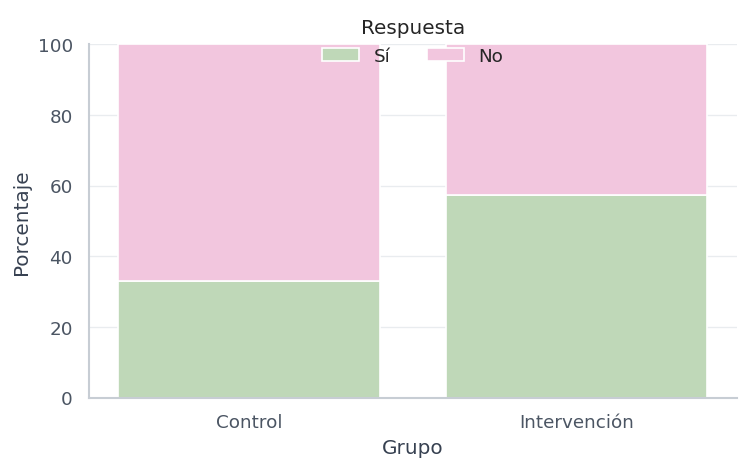

In [11]:
fig, ax = plt.subplots()
bottom = np.zeros(len(orden))
colors = {"Sí": PASTEL["salvia"], "No": PASTEL["rosa"]}
for respuesta in ["Sí", "No"]:
    vals = proporciones.loc[orden, respuesta].values
    ax.bar(orden, vals, bottom=bottom, label=respuesta, color=colors[respuesta], edgecolor="white", linewidth=1)
    bottom += vals
ax.set(xlabel="Grupo", ylabel="Porcentaje", ylim=(0, 100))
ax.legend(title="Respuesta", ncols=2, loc="upper center", bbox_to_anchor=(0.5, 1.12))
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

(relaciones)=
## Relaciones

### Diagrama de dispersión

:::{tip} Cuándo usarlo
:class: simple
**Úsalo para:** ver dirección, forma, heterogeneidad y observaciones atípicas entre dos variables cuantitativas.  
**Evita:** resumir relaciones con demasiada sobreposición; con grandes n conviene transparencia, hexbin o densidad.
:::

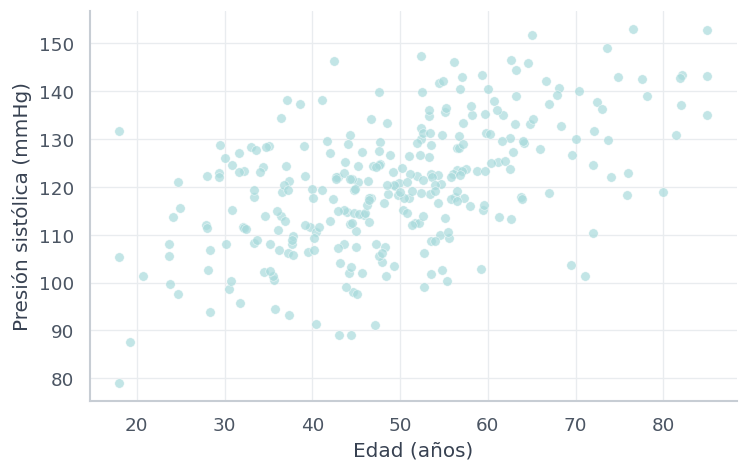

In [12]:
fig, ax = plt.subplots()
sns.scatterplot(data=df, x="edad", y="presion_sistolica", color=PASTEL["azul"], alpha=0.7, s=32, edgecolor="white", linewidth=0.35, ax=ax)
ax.set(xlabel="Edad (años)", ylabel="Presión sistólica (mmHg)")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Dispersión con tendencia

:::{tip} Cuándo usarlo
:class: simple
**Úsalo para:** mostrar los datos y una tendencia promedio en la misma figura.  
**Evita:** presentar una recta como causal o apropiada sin revisar primero la forma de la relación.
:::

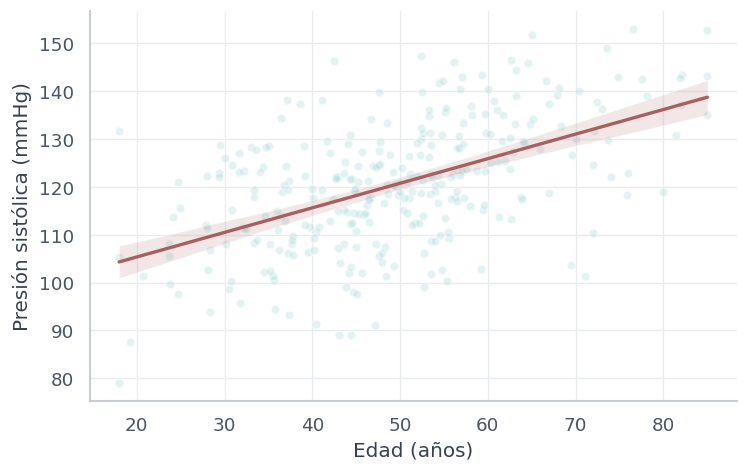

In [13]:
fig, ax = plt.subplots()
sns.regplot(
    data=df, x="edad", y="presion_sistolica", ci=95,
    scatter_kws={"alpha": 0.35, "s": 26, "color": PASTEL["azul"], "edgecolor": "white"},
    line_kws={"color": DARK["coral"], "linewidth": 2},
    color=PASTEL["coral"], ax=ax,
)
ax.set(xlabel="Edad (años)", ylabel="Presión sistólica (mmHg)")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Hexbin

:::{tip} Cuándo usarlo
:class: simple
**Úsalo para:** mostrar concentración de puntos cuando un scatter está saturado.  
**Evita:** muestras pequeñas: el binning sacrifica observaciones individuales sin aportar claridad.
:::

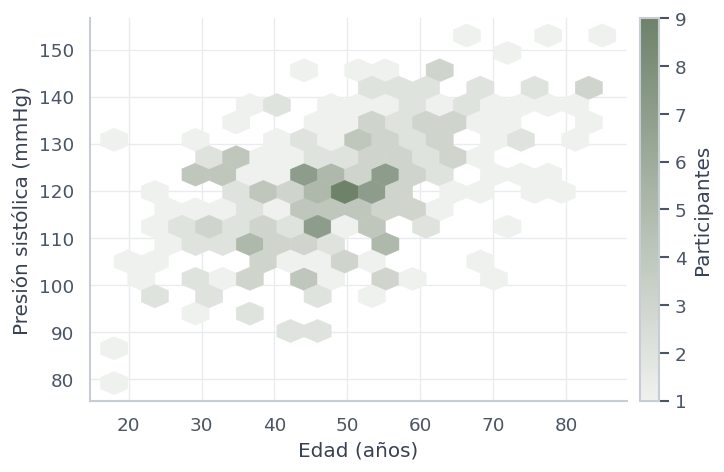

In [14]:
fig, ax = plt.subplots()
hb = ax.hexbin(df["edad"], df["presion_sistolica"], gridsize=18, mincnt=1, cmap=hex_cmap, linewidths=0.3)
ax.set(xlabel="Edad (años)", ylabel="Presión sistólica (mmHg)")
cb = fig.colorbar(hb, ax=ax, pad=0.02)
cb.set_label("Participantes")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Gráfico de burbujas

:::{tip} Cuándo usarlo
:class: simple
**Úsalo para:** representar tres dimensiones cuantitativas: x, y y tamaño; el color puede añadir un grupo.  
**Evita:** comparaciones precisas del tamaño o demasiadas burbujas superpuestas; el área se estima con poca precisión.
:::

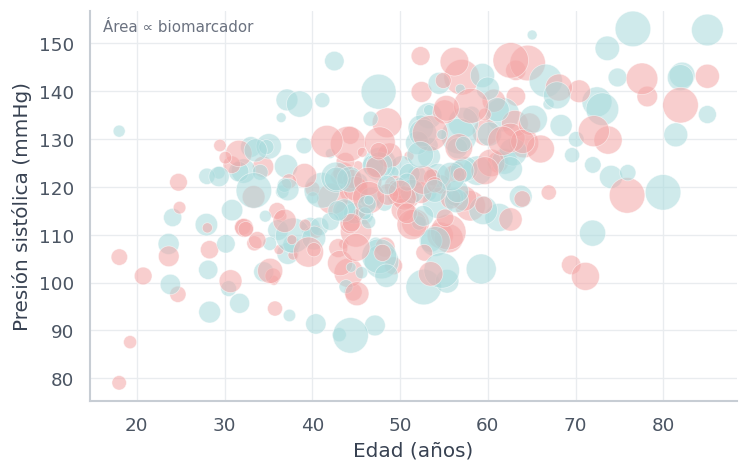

In [15]:
fig, ax = plt.subplots()
sns.scatterplot(
    data=df, x="edad", y="presion_sistolica", hue="grupo", hue_order=orden,
    palette=paleta, size=bubble_size, sizes=(35, 455), alpha=0.55,
    edgecolor="white", linewidth=0.45, legend=False, ax=ax,
)
ax.set(xlabel="Edad (años)", ylabel="Presión sistólica (mmHg)")
ax.text(0.02, 0.98, "Área ∝ biomarcador", transform=ax.transAxes, va="top", color=DARK["gris"], fontsize=9)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Mapa de calor de correlaciones

:::{tip} Cuándo usarlo
:class: simple
**Úsalo para:** examinar rápidamente un patrón de correlaciones entre varias variables cuantitativas.  
**Evita:** usarlo como sustituto del scatter o para inferir causalidad; además puede ocultar relaciones no lineales.
:::

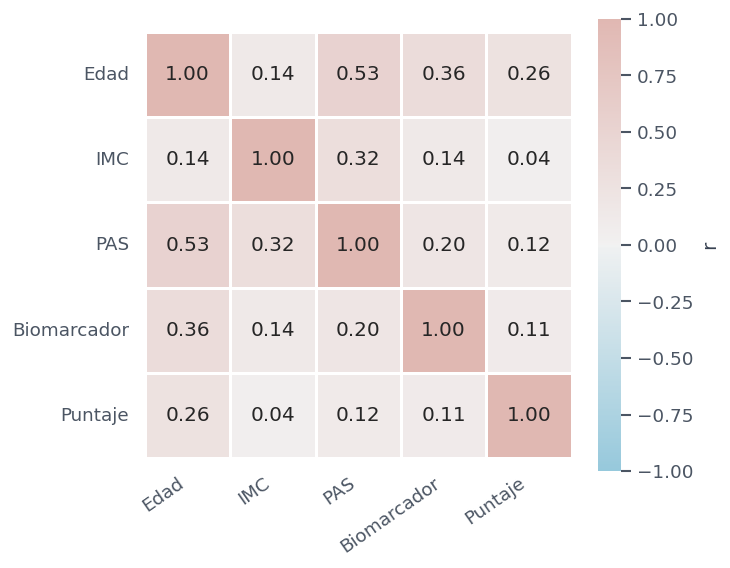

In [16]:
fig, ax = plt.subplots(figsize=(6.2, 5.0))
sns.heatmap(
    matriz_corr, annot=True, fmt=".2f", center=0, vmin=-1, vmax=1,
    cmap=corr_cmap, square=True, linewidths=0.8, linecolor="white",
    cbar_kws={"label": "r"}, ax=ax,
)
ax.set_xticklabels(["Edad", "IMC", "PAS", "Biomarcador", "Puntaje"], rotation=35, ha="right")
ax.set_yticklabels(["Edad", "IMC", "PAS", "Biomarcador", "Puntaje"], rotation=0)
plt.tight_layout()
plt.show()

(comparaciones)=
## Comparaciones

### Boxplot por grupos

:::{tip} Cuándo usarlo
:class: simple
**Úsalo para:** comparar mediana y dispersión de una variable cuantitativa entre categorías.  
**Evita:** concluir que dos grupos son iguales o diferentes solo por el solapamiento de las cajas.
:::

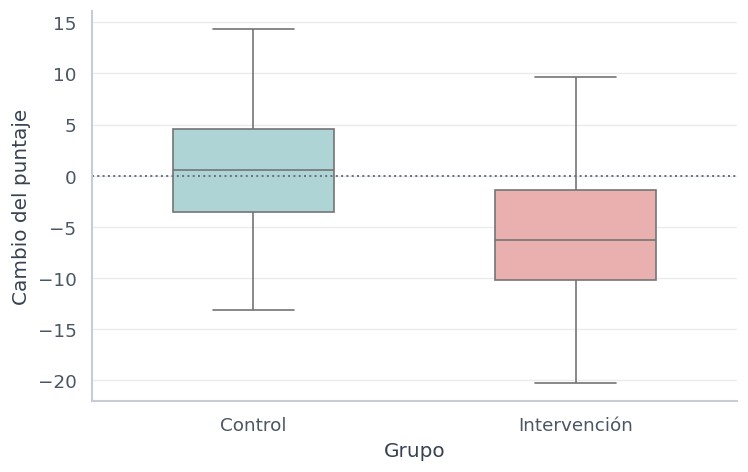

In [17]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x="grupo", y="cambio_puntaje", order=orden, hue="grupo", palette=paleta, legend=False, width=0.5, ax=ax)
ax.axhline(0, color=DARK["gris"], linestyle=":", linewidth=1.2)
ax.set(xlabel="Grupo", ylabel="Cambio del puntaje")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Violin plot por grupos

:::{tip} Cuándo usarlo
:class: simple
**Úsalo para:** comparar forma y posición de varias distribuciones.  
**Evita:** grupos pequeños o figuras donde el suavizado complique más de lo que aclara.
:::

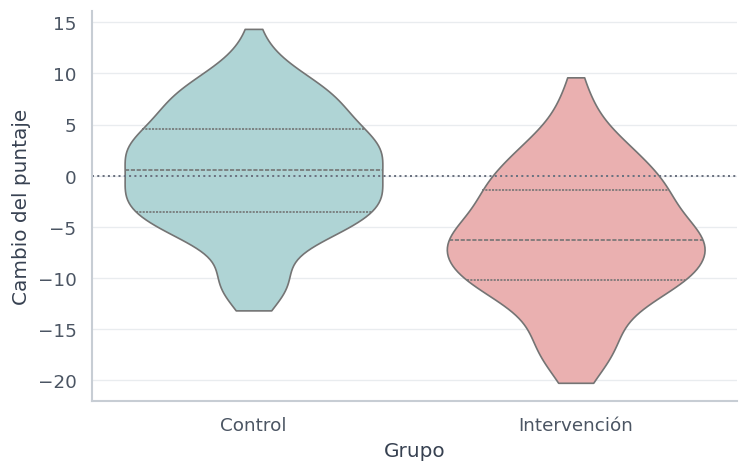

In [18]:
fig, ax = plt.subplots()
sns.violinplot(data=df, x="grupo", y="cambio_puntaje", order=orden, hue="grupo", palette=paleta, legend=False, inner="quart", cut=0, linewidth=1, ax=ax)
ax.axhline(0, color=DARK["gris"], linestyle=":", linewidth=1.2)
ax.set(xlabel="Grupo", ylabel="Cambio del puntaje")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Raincloud plot

:::{tip} Cuándo usarlo
:class: simple
**Úsalo para:** mostrar al mismo tiempo distribución, resumen y observaciones individuales.  
**Evita:** muestras muy grandes sin controlar opacidad/jitter o figuras pequeñas donde termine saturado.
:::

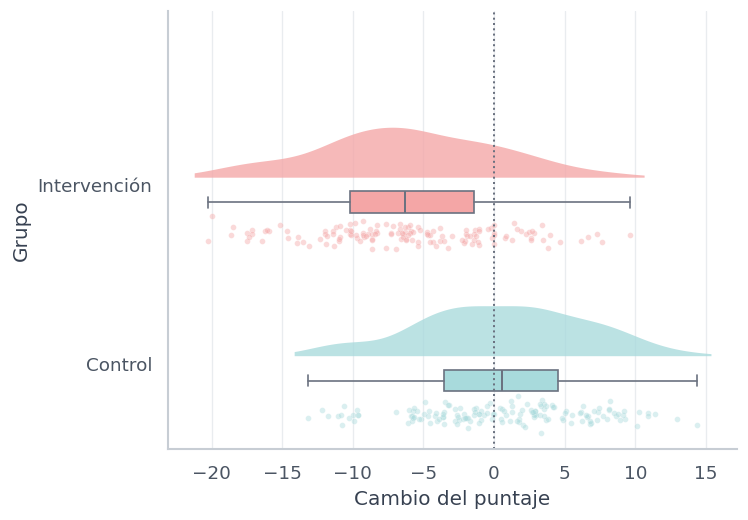

In [19]:
fig, ax = plt.subplots(figsize=(6.4, 4.5))
for i, g in enumerate(orden):
    rc = raincloud[g]
    color = paleta[g]
    ax.fill_between(
        rc["grid"], i + 0.04, i + 0.04 + rc["density"],
        color=color, alpha=0.78, linewidth=0,
    )
    ax.boxplot(
        rc["values"], positions=[i - 0.10], vert=False, widths=0.12,
        patch_artist=True, showfliers=False, manage_ticks=False,
        boxprops={"facecolor": color, "edgecolor": DARK["gris"], "linewidth": 1},
        medianprops={"color": DARK["gris"], "linewidth": 1.2},
        whiskerprops={"color": DARK["gris"], "linewidth": 1},
        capprops={"color": DARK["gris"], "linewidth": 1},
    )
    ax.scatter(
        rc["values"], i - 0.29 + rc["jitter"], s=12,
        color=color, alpha=0.42, edgecolor="white", linewidth=0.25,
    )
ax.axvline(0, color=DARK["gris"], linestyle=":", linewidth=1.2)
ax.set_yticks(range(len(orden)), orden)
ax.set_ylim(-0.48, len(orden) - 0.58 + 0.55)
ax.set(xlabel="Cambio del puntaje", ylabel="Grupo")
ax.grid(axis="y", visible=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

(longitudinales)=
## Pareados y longitudinales

### Basal vs. final

:::{tip} Cuándo usarlo
:class: simple
**Úsalo para:** conservar el emparejamiento individual de dos mediciones y compararlas contra la diagonal de igualdad.  
**Evita:** leer distancia a la diagonal como efecto causal o ignorar regresión a la media.
:::

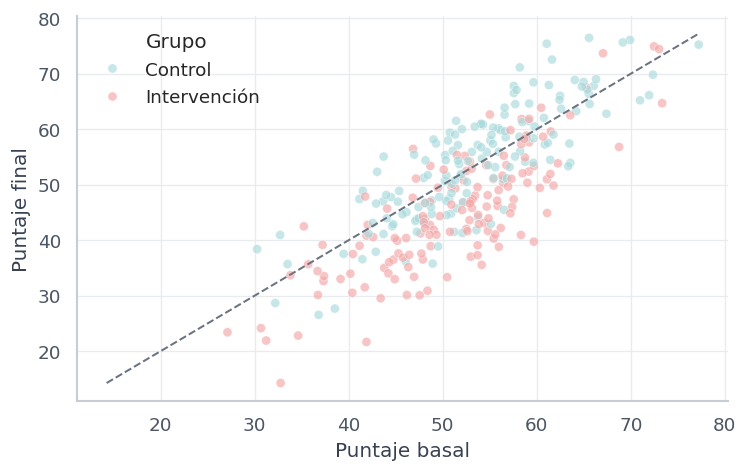

In [20]:
fig, ax = plt.subplots()
sns.scatterplot(data=df, x="puntaje_basal", y="puntaje_final", hue="grupo", hue_order=orden, palette=paleta, alpha=0.65, s=30, edgecolor="white", linewidth=0.35, ax=ax)
lo = df[["puntaje_basal", "puntaje_final"]].min().min()
hi = df[["puntaje_basal", "puntaje_final"]].max().max()
ax.plot([lo, hi], [lo, hi], color=DARK["gris"], linestyle="--", linewidth=1.2)
ax.set(xlabel="Puntaje basal", ylabel="Puntaje final")
ax.legend(title="Grupo")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Trayectorias individuales

:::{tip} Cuándo usarlo
:class: simple
**Úsalo para:** mostrar dirección y heterogeneidad del cambio dentro de cada participante.  
**Evita:** dibujar cientos de líneas; con n grande conviene muestrear trayectorias o resumir la distribución del cambio.
:::

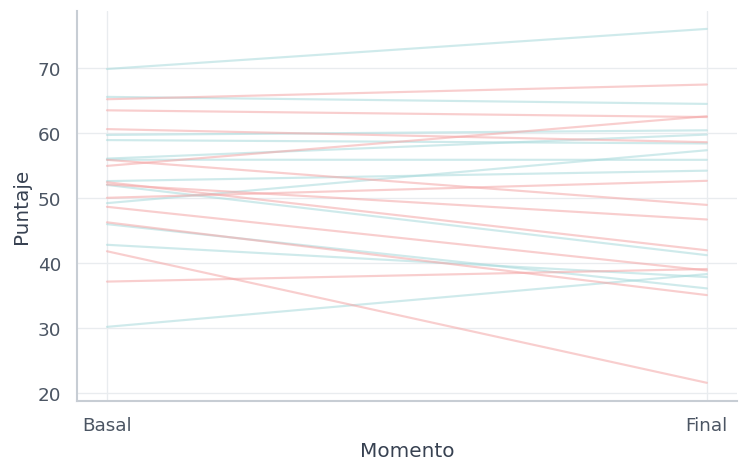

In [21]:
fig, ax = plt.subplots()
sns.lineplot(
    data=seleccion_trayectorias, x="momento", y="puntaje", hue="grupo",
    units="id", estimator=None, hue_order=orden, palette=paleta,
    alpha=0.55, linewidth=1.3, legend=False, ax=ax,
)
ax.set(xlabel="Momento", ylabel="Puntaje")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Tendencia grupal

:::{tip} Cuándo usarlo
:class: simple
**Úsalo para:** resumir el cambio promedio de cada grupo a través de momentos definidos.  
**Evita:** conectar momentos muy separados como si describieran la trayectoria intermedia o esconder heterogeneidad individual.
:::

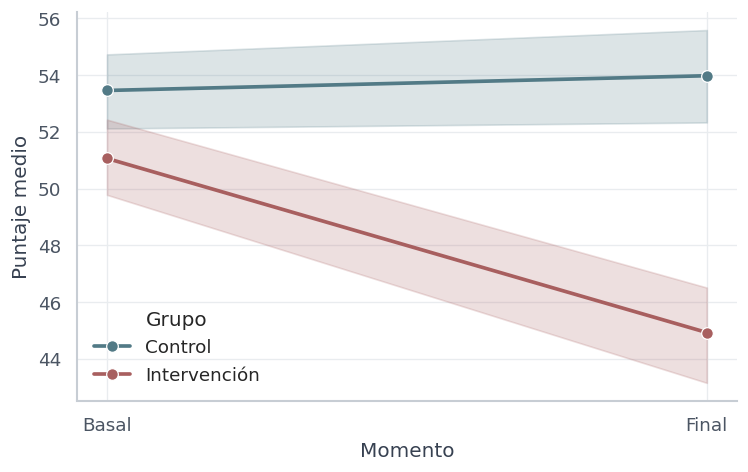

In [22]:
fig, ax = plt.subplots()
sns.lineplot(
    data=longitudinal, x="momento", y="puntaje", hue="grupo", hue_order=orden,
    palette={"Control": DARK["azul"], "Intervención": DARK["coral"]},
    estimator="mean", errorbar=("ci", 95), marker="o", markersize=7, linewidth=2.2, ax=ax,
)
ax.set(xlabel="Momento", ylabel="Puntaje medio")
ax.legend(title="Grupo")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

(estimaciones)=
## Estimaciones e incertidumbre

### Estimación puntual e IC 95 %

:::{tip} Cuándo usarlo
:class: simple
**Úsalo para:** comunicar magnitud y precisión de una estimación en una figura compacta.  
**Evita:** reducir la interpretación a si el intervalo cruza o no un valor nulo.
:::

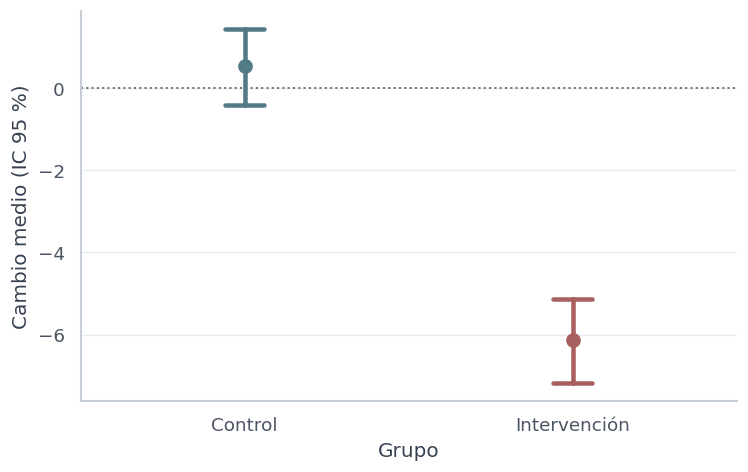

In [23]:
fig, ax = plt.subplots()
sns.pointplot(
    data=df, x="grupo", y="cambio_puntaje", order=orden, hue="grupo",
    palette={"Control": DARK["azul"], "Intervención": DARK["coral"]},
    legend=False, estimator="mean", errorbar=("ci", 95), n_boot=4000,
    seed=42, markers="o", linestyles="none", capsize=0.12, ax=ax,
)
ax.axhline(0, color=DARK["gris"], linestyle=":", linewidth=1.2)
ax.set(xlabel="Grupo", ylabel="Cambio medio (IC 95 %)")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Forest plot

:::{tip} Cuándo usarlo
:class: simple
**Úsalo para:** mostrar varias estimaciones con sus intervalos de confianza sobre una misma escala.  
**Evita:** comparar subgrupos por 'significativo/no significativo'; la heterogeneidad requiere una prueba de interacción.
:::

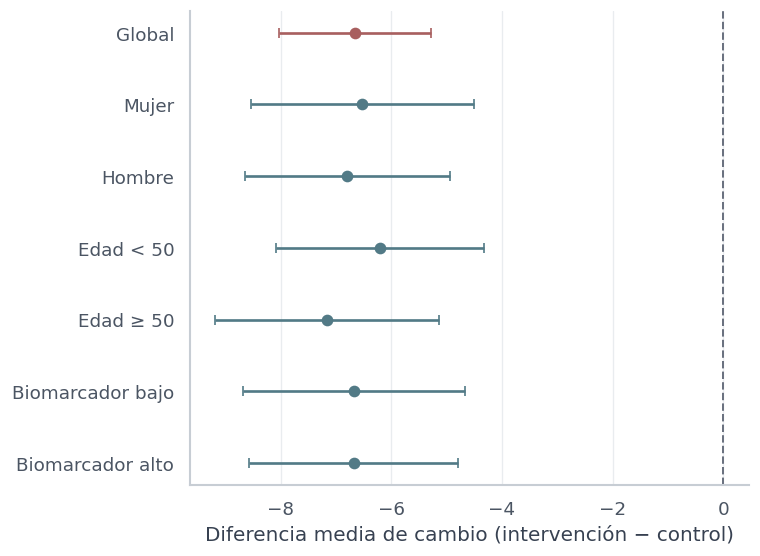

In [24]:
fig, ax = plt.subplots(figsize=(6.5, 4.8))
plot_df = forest.iloc[::-1].reset_index(drop=True)
y = np.arange(len(plot_df))
for i, row in plot_df.iterrows():
    color = DARK["coral"] if row["subgrupo"] == "Global" else DARK["azul"]
    ax.errorbar(
        row["estimacion"], i,
        xerr=[[row["estimacion"] - row["inferior"]], [row["superior"] - row["estimacion"]]],
        fmt="o", color=color, ecolor=color, elinewidth=1.6, capsize=3, markersize=6,
    )
ax.axvline(0, color=DARK["gris"], linestyle="--", linewidth=1.2)
ax.set_yticks(y, plot_df["subgrupo"])
ax.set(xlabel="Diferencia media de cambio (intervención − control)", ylabel="")
ax.grid(axis="y", visible=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

(clinicos)=
## Gráficos clínicos especializados

### Curva ROC

:::{tip} Cuándo usarlo
:class: simple
**Úsalo para:** describir discriminación de una prueba a través de distintos umbrales.  
**Evita:** interpretarla como calibración, utilidad clínica o evidencia de causalidad; el AUC no informa todo eso.
:::

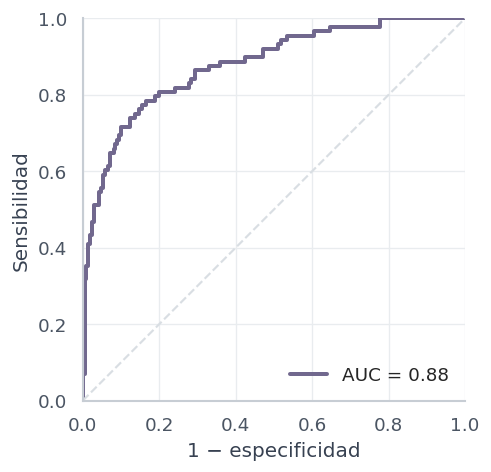

In [25]:
fig, ax = plt.subplots()
ax.plot(fpr, tpr, color=DARK["lila"], linewidth=2.4, label=f"AUC = {auc:.2f}")
ax.plot([0, 1], [0, 1], color=PASTEL["gris"], linestyle="--", linewidth=1.3)
ax.set(xlabel="1 − especificidad", ylabel="Sensibilidad", xlim=(0, 1), ylim=(0, 1))
ax.legend(loc="lower right")
ax.set_aspect("equal", adjustable="box")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Gráfico de calibración

:::{tip} Cuándo usarlo
:class: simple
**Úsalo para:** comparar probabilidades predichas con frecuencias observadas.  
**Evita:** evaluar discriminación; una prueba puede discriminar bien y estar mal calibrada, o al revés.
:::

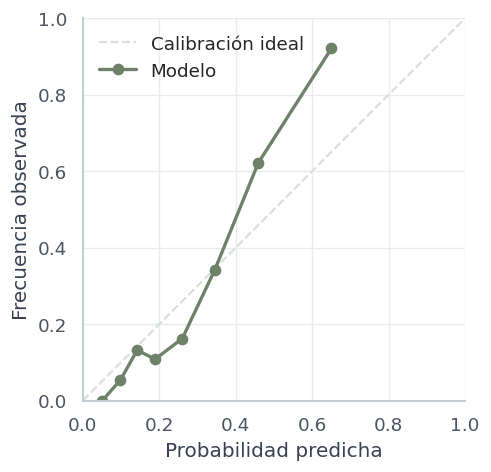

In [26]:
fig, ax = plt.subplots()
ax.plot([0, 1], [0, 1], color=PASTEL["gris"], linestyle="--", linewidth=1.3, label="Calibración ideal")
ax.plot(cal_mean_pred, cal_frac_pos, marker="o", markersize=6, color=DARK["salvia"], linewidth=2, label="Modelo")
ax.set(xlabel="Probabilidad predicha", ylabel="Frecuencia observada", xlim=(0, 1), ylim=(0, 1))
ax.legend(loc="upper left")
ax.set_aspect("equal", adjustable="box")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Bland–Altman

:::{tip} Cuándo usarlo
:class: simple
**Úsalo para:** evaluar acuerdo entre dos métodos de medición y buscar sesgo o patrones dependientes de la magnitud.  
**Evita:** sustituirlo por correlación: alta correlación no implica acuerdo.
:::

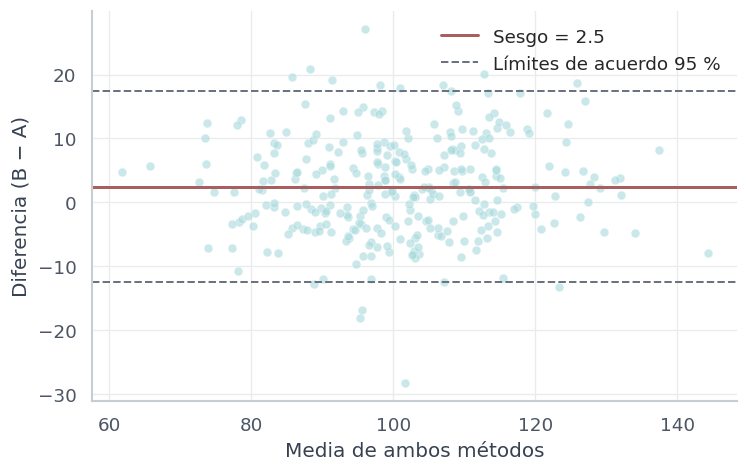

In [27]:
fig, ax = plt.subplots()
ax.scatter(concordancia["media"], concordancia["diferencia"], s=28, alpha=0.6, color=PASTEL["azul"], edgecolor="white", linewidth=0.35)
ax.axhline(sesgo, color=DARK["coral"], linewidth=1.8, label=f"Sesgo = {sesgo:.1f}")
ax.axhline(loa_inf, color=DARK["gris"], linestyle="--", linewidth=1.2)
ax.axhline(loa_sup, color=DARK["gris"], linestyle="--", linewidth=1.2, label="Límites de acuerdo 95 %")
ax.set(xlabel="Media de ambos métodos", ylabel="Diferencia (B − A)")
ax.legend(loc="upper right")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Kaplan–Meier

:::{tip} Cuándo usarlo
:class: simple
**Úsalo para:** mostrar la probabilidad acumulada de permanecer libre de evento a lo largo del tiempo con censura.  
**Evita:** leer separación de curvas como hazard ratio o como diferencia causal sin un análisis apropiado.
:::

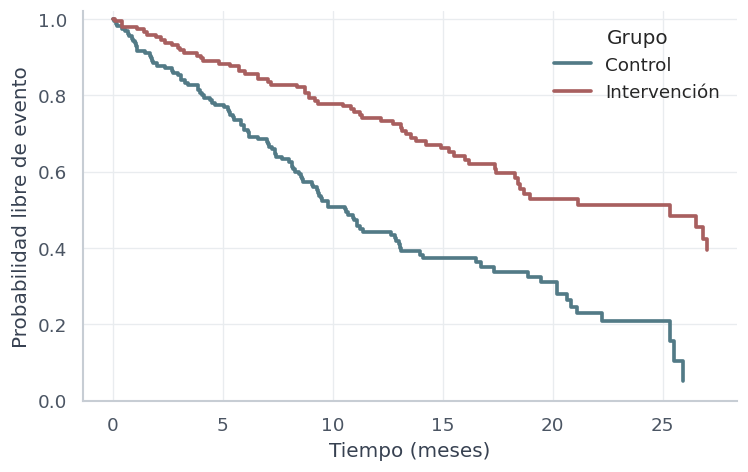

In [28]:
fig, ax = plt.subplots()
for g in orden:
    t, s = km[g]
    ax.step(t, s, where="post", linewidth=2.2, color=DARK["azul"] if g == "Control" else DARK["coral"], label=g)
ax.set(xlabel="Tiempo (meses)", ylabel="Probabilidad libre de evento", ylim=(0, 1.02))
ax.legend(title="Grupo")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

(evitar)=
## Qué conviene evitar

:::{warning} Diseños que suelen empeorar la comunicación científica
:class: simple
- **3D** cuando la tercera dimensión no representa datos: distorsiona longitudes y áreas.
- **Doble eje Y** para insinuar relaciones entre series con escalas distintas: la apariencia cambia al reescalar.
- **Barras con eje truncado**: exageran diferencias porque la longitud deja de representar la magnitud desde cero.
- **Paletas arcoíris** para magnitudes ordenadas: introducen discontinuidades perceptuales y dificultan lectura y accesibilidad.
- **Demasiadas categorías apiladas, líneas o colores**: si el lector necesita una leyenda para reconstruir la figura, suele ser momento de simplificar o dividir.
:::